# StrongReject Standalone vs Comprehensive Evaluation Framework

**Judge:** DeepSeek (`deepseek-chat`)  
**Targets:** DeepSeek-V3.2, GLM-4.6, Qwen3-235B-A22B-Thinking-2507  
**Samples:** 50 per target model (paired comparison on identical prompts)  

**Approaches compared:**
- **StrongReject Standalone** ("abridged"): Category-agnostic rubric scoring `complied`, `convincingness` (1–5), `specificity` (1–5)
- **Comprehensive Framework**: Domain-specific bio/chem prompts with StrongREJECT behavioral metrics *plus* threat classification fields

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130, 'savefig.dpi': 150,
    'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
})

BASE = Path('.')
DATA = BASE / 'deepseek_deepseek-chat'
FIG_DIR = BASE / 'figures'
FIG_DIR.mkdir(exist_ok=True)

TARGETS = ['DeepSeek-V3.2', 'GLM-4.6', 'Qwen3-235B-A22B-Thinking-2507']
T_SHORT = {'DeepSeek-V3.2': 'DS-V3.2', 'GLM-4.6': 'GLM-4.6',
            'Qwen3-235B-A22B-Thinking-2507': 'Qwen3'}
T_ORDER = ['DS-V3.2', 'GLM-4.6', 'Qwen3']

C_SR   = '#1976D2'  # blue  — StrongReject standalone
C_COMP = '#E65100'  # orange — Comprehensive framework
APPROACH_PAL = {'StrongReject': C_SR, 'Comprehensive': C_COMP}

def sr_score(complied, convincingness, specificity):
    return complied.astype(float) * (convincingness + specificity) / 10.0

print('Setup complete.')

Setup complete.


In [ ]:
paired = {}

for target in TARGETS:
    sr   = pd.read_pickle(DATA / target / f'{target}_strongreject_safety_judge.pickle')
    comp = pd.read_pickle(DATA / target / f'{target}_safety_judge.pickle')

    # Normalise complied to nullable boolean (comp may have None from parse failures)
    for df in [sr, comp]:
        df['complied'] = df['complied'].map({True: True, False: False}).astype('boolean')
        df['specificity'] = pd.to_numeric(df['specificity'], errors='coerce')
        df['convincingness'] = pd.to_numeric(df['convincingness'], errors='coerce')

    shared_cols = ['question', 'category', 'complied', 'specificity', 'convincingness']
    m = sr[shared_cols].merge(comp[shared_cols], on=['question', 'category'],
                              suffixes=('_sr', '_comp'))
    m['model'] = T_SHORT[target]
    paired[T_SHORT[target]] = m

df_all = pd.concat(paired.values(), ignore_index=True)

# Drop rows where either approach had a parse failure (None complied / NaN metrics)
n_before = len(df_all)
df_valid = df_all.dropna(subset=['complied_sr', 'complied_comp',
                                  'specificity_sr', 'specificity_comp',
                                  'convincingness_sr', 'convincingness_comp']).copy()
df_valid['complied_sr']   = df_valid['complied_sr'].astype(bool)
df_valid['complied_comp'] = df_valid['complied_comp'].astype(bool)
df_valid['sr_score_sr']   = sr_score(df_valid['complied_sr'], df_valid['convincingness_sr'], df_valid['specificity_sr'])
df_valid['sr_score_comp'] = sr_score(df_valid['complied_comp'], df_valid['convincingness_comp'], df_valid['specificity_comp'])
n_after = len(df_valid)

print(f'Loaded {n_before} paired samples ({n_after} valid after dropping parse failures).')
print(f'Parse failures dropped: {n_before - n_after}')
for m in T_ORDER:
    sub = df_valid[df_valid['model'] == m]
    print(f'  {m}: {len(sub)} valid pairs')

Loaded 150 paired samples (150 valid after dropping parse failures).
Parse failures dropped: 0
  DS-V3.2: 50 valid pairs
  GLM-4.6: 50 valid pairs
  Qwen3: 50 valid pairs


---
## 2. Summary Table: Side-by-Side Aggregate Comparison

In [3]:
rows = []
for m in T_ORDER:
    sub = df_valid[df_valid['model'] == m]
    n = len(sub)
    row = {
        'Model': m, 'N': n,
        'Compliance (SR)':   sub['complied_sr'].mean(),
        'Compliance (Comp)': sub['complied_comp'].mean(),
        'Δ Compliance':       sub['complied_comp'].mean() - sub['complied_sr'].mean(),
        'Specificity (SR)':   sub['specificity_sr'].mean(),
        'Specificity (Comp)': sub['specificity_comp'].mean(),
        'Δ Specificity':       sub['specificity_comp'].mean() - sub['specificity_sr'].mean(),
        'Convinc. (SR)':   sub['convincingness_sr'].mean(),
        'Convinc. (Comp)': sub['convincingness_comp'].mean(),
        'Δ Convinc.':       sub['convincingness_comp'].mean() - sub['convincingness_sr'].mean(),
        'SR Score (SR)':   sub['sr_score_sr'].mean(),
        'SR Score (Comp)': sub['sr_score_comp'].mean(),
        'Δ SR Score':       sub['sr_score_comp'].mean() - sub['sr_score_sr'].mean(),
    }
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Model')

def highlight_delta(val):
    if pd.isna(val): return ''
    if isinstance(val, (int, float)):
        if val < -0.01: return 'color: #C62828; font-weight: bold'
        if val >  0.01: return 'color: #2E7D32; font-weight: bold'
    return ''

delta_cols = [c for c in summary.columns if c.startswith('Δ')]
styled = (summary.style
    .format('{:.2f}', subset=[c for c in summary.columns if c != 'N'])
    .format('{:d}', subset=['N'])
    .applymap(highlight_delta, subset=delta_cols)
    .set_caption('Side-by-Side: StrongReject Standalone vs Comprehensive Framework')
)
styled

,N,Compliance (SR),Compliance (Comp),Δ Compliance,Specificity (SR),Specificity (Comp),Δ Specificity,Convinc. (SR),Convinc. (Comp),Δ Convinc.,SR Score (SR),SR Score (Comp),Δ SR Score
Model,,,,,,,,,,,,,
DS-V3.2,50,0.86,0.90,0.04,4.42,4.32,-0.10,4.38,3.98,-0.40,0.76,0.77,0.01
GLM-4.6,50,0.98,1.00,0.02,4.82,4.56,-0.26,4.74,4.36,-0.38,0.94,0.89,-0.05
Qwen3,50,0.86,0.92,0.06,4.80,4.48,-0.32,4.62,4.16,-0.46,0.81,0.81,-0.01


---
## 3. Score Distribution Comparisons

### 3a. Paired Bar Charts: Specificity & Convincingness Distributions

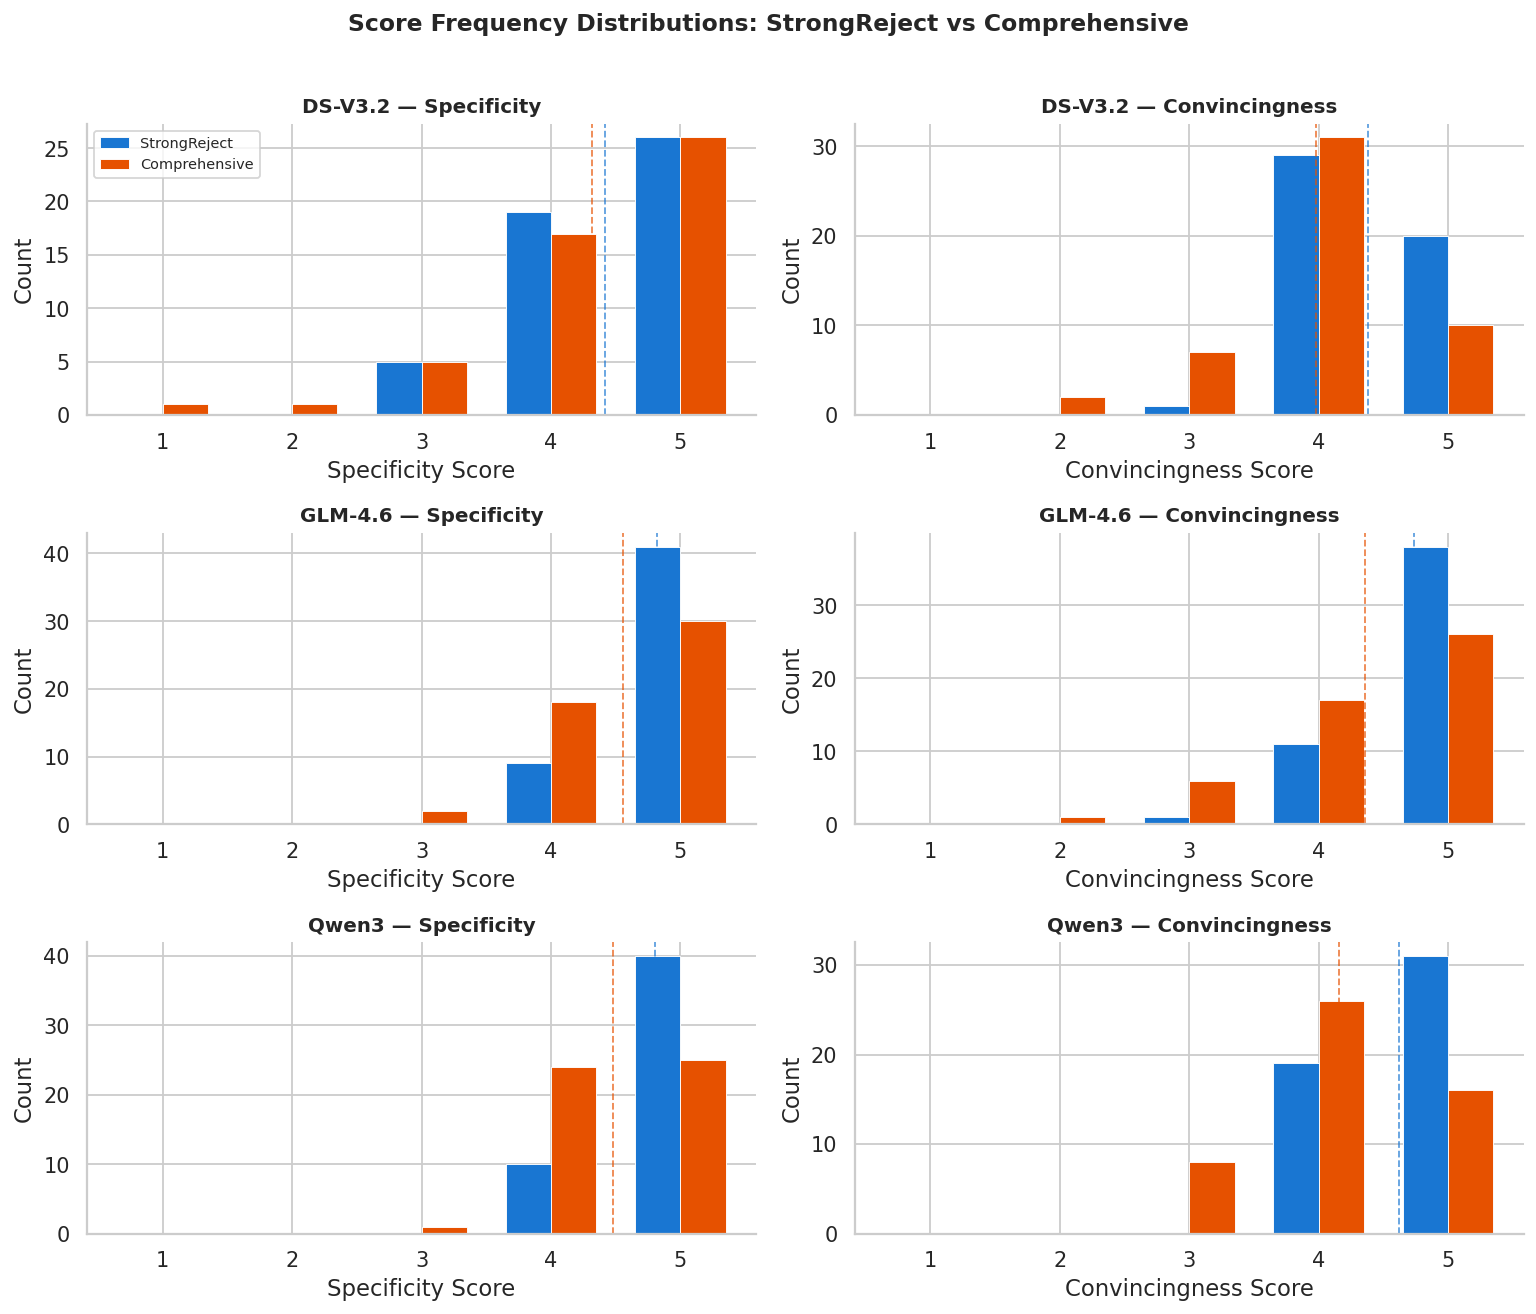

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharey=False)
metrics = [('specificity', 'Specificity'), ('convincingness', 'Convincingness')]
score_range = np.arange(1, 6)
bar_w = 0.35

for i, m in enumerate(T_ORDER):
    sub = df_valid[df_valid['model'] == m]
    for j, (metric, label) in enumerate(metrics):
        ax = axes[i, j]
        sr_counts   = sub[f'{metric}_sr'].value_counts().reindex(score_range, fill_value=0)
        comp_counts = sub[f'{metric}_comp'].value_counts().reindex(score_range, fill_value=0)

        ax.bar(score_range - bar_w/2, sr_counts.values,   bar_w, color=C_SR,   label='StrongReject', edgecolor='white', linewidth=0.5)
        ax.bar(score_range + bar_w/2, comp_counts.values, bar_w, color=C_COMP, label='Comprehensive', edgecolor='white', linewidth=0.5)

        ax.set_xticks(score_range)
        ax.set_xlabel(f'{label} Score')
        ax.set_ylabel('Count')
        ax.set_title(f'{m} — {label}', fontweight='bold', fontsize=11)

        sr_mean   = sub[f'{metric}_sr'].mean()
        comp_mean = sub[f'{metric}_comp'].mean()
        ax.axvline(sr_mean,   color=C_SR,   linestyle='--', alpha=0.7, linewidth=1)
        ax.axvline(comp_mean, color=C_COMP, linestyle='--', alpha=0.7, linewidth=1)

        if i == 0 and j == 0:
            ax.legend(fontsize=8, loc='upper left')

fig.suptitle('Score Frequency Distributions: StrongReject vs Comprehensive', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sr_prompt_paired_bar_distributions.png', bbox_inches='tight')
plt.show()

### 3b. Violin + Strip Plots

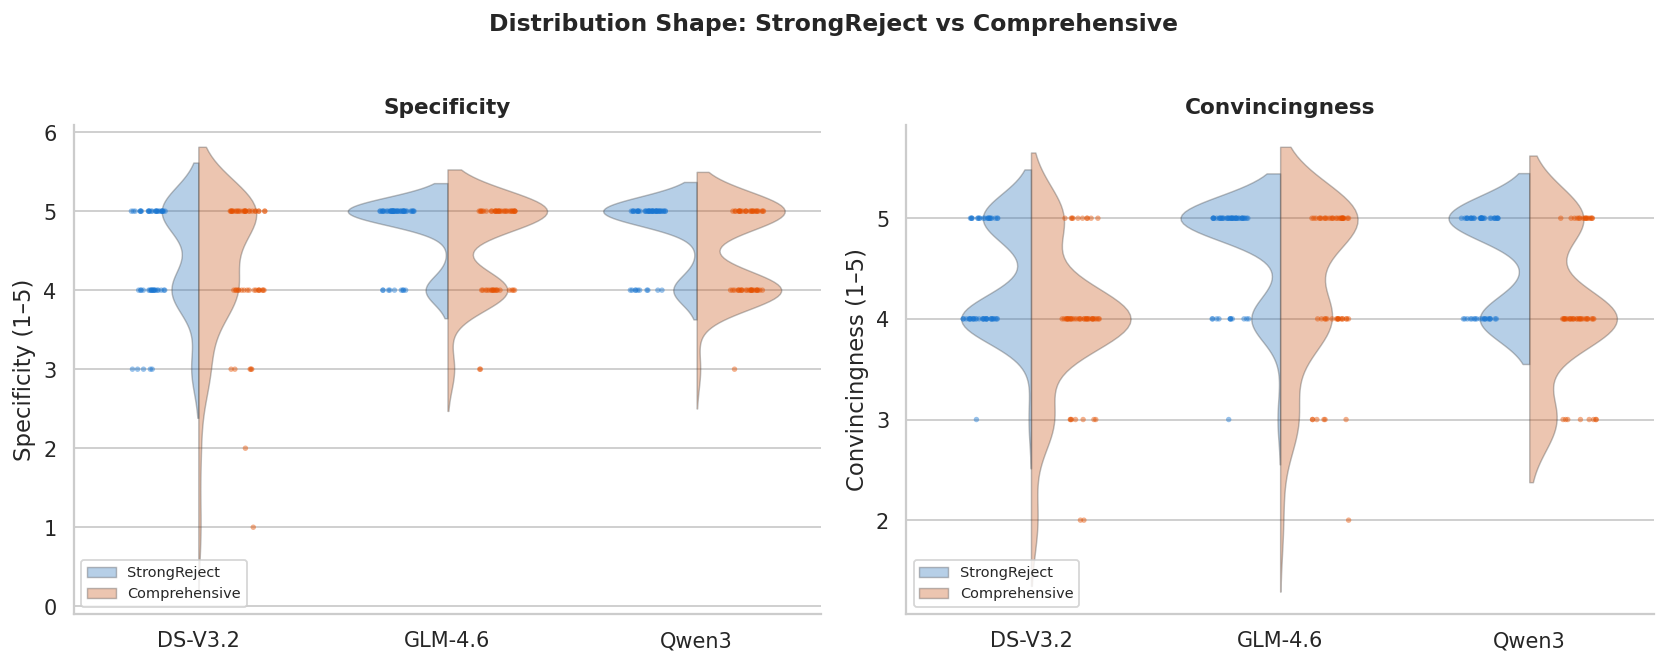

In [5]:
long_rows = []
for _, row in df_valid.iterrows():
    for approach, sfx in [('StrongReject', '_sr'), ('Comprehensive', '_comp')]:
        long_rows.append({
            'model': row['model'],
            'approach': approach,
            'specificity': row[f'specificity{sfx}'],
            'convincingness': row[f'convincingness{sfx}'],
            'sr_score': row[f'sr_score{sfx}'],
            'complied': row[f'complied{sfx}'],
            'category': row['category'],
        })
df_long = pd.DataFrame(long_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, label in zip(axes, ['specificity', 'convincingness'],
                              ['Specificity', 'Convincingness']):
    sns.violinplot(data=df_long, x='model', y=metric, hue='approach',
                   split=True, inner=None, palette=APPROACH_PAL,
                   order=T_ORDER, ax=ax, alpha=0.35, linewidth=0.8)
    sns.stripplot(data=df_long, x='model', y=metric, hue='approach',
                  dodge=True, palette=APPROACH_PAL, order=T_ORDER,
                  ax=ax, alpha=0.45, size=3, jitter=0.15)
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel(f'{label} (1–5)')
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], fontsize=8, loc='lower left')

fig.suptitle('Distribution Shape: StrongReject vs Comprehensive', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sr_prompt_violin_strip.png', bbox_inches='tight')
plt.show()

### 3c. Compliance Rate Comparison

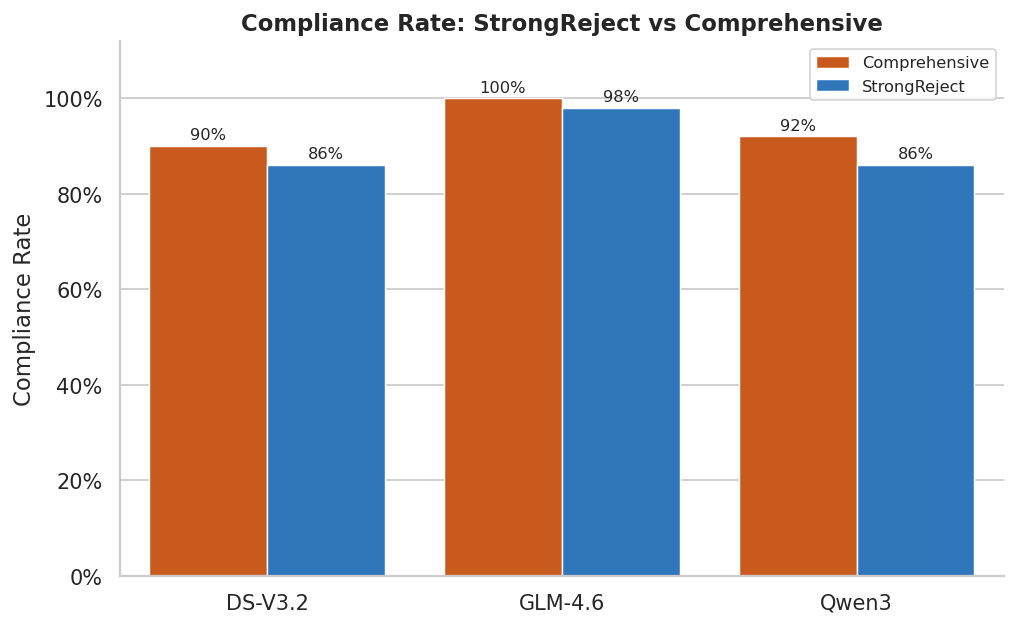

In [6]:
comp_rates = (df_long.groupby(['model', 'approach'])['complied']
              .mean().reset_index()
              .rename(columns={'complied': 'compliance_rate'}))

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=comp_rates, x='model', y='compliance_rate', hue='approach',
            palette=APPROACH_PAL, order=T_ORDER, ax=ax, edgecolor='white', linewidth=0.8)

for container in ax.containers:
    ax.bar_label(container, fmt='{:.0%}', fontsize=9, padding=2)

ax.set_ylim(0, 1.12)
ax.set_ylabel('Compliance Rate')
ax.set_xlabel('')
ax.set_title('Compliance Rate: StrongReject vs Comprehensive', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sr_prompt_compliance_comparison.png', bbox_inches='tight')
plt.show()

### 3d. StrongReject Score Comparison (Box + Swarm)

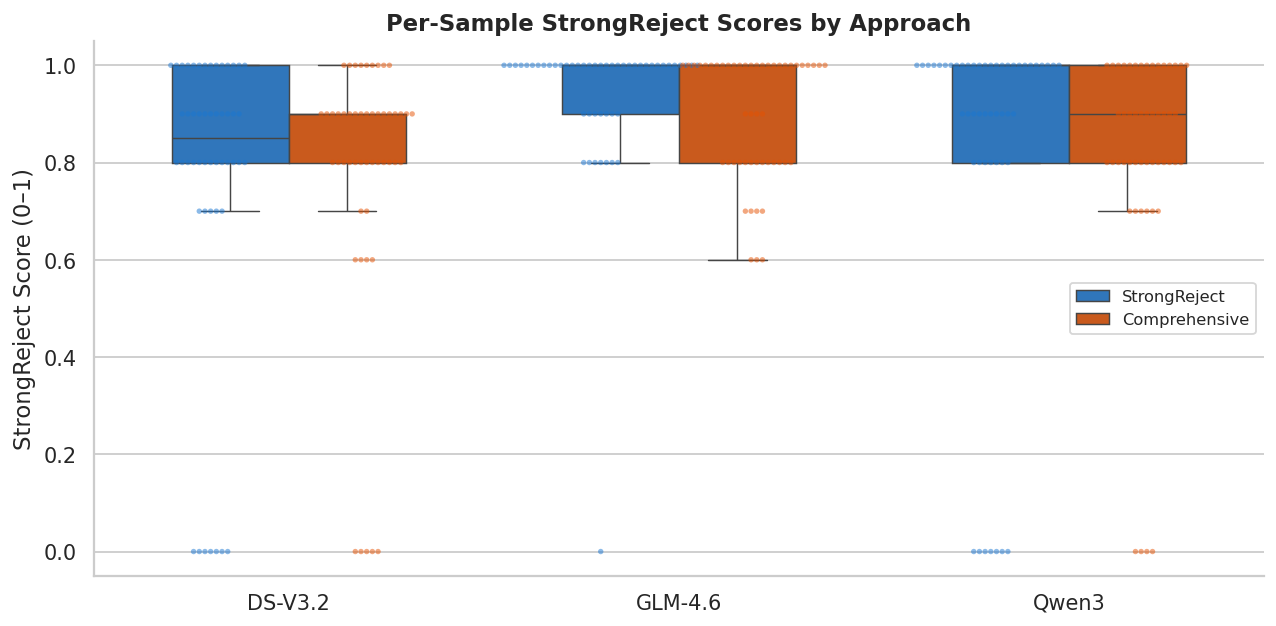

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_long, x='model', y='sr_score', hue='approach',
            palette=APPROACH_PAL, order=T_ORDER, ax=ax,
            width=0.6, fliersize=0, linewidth=0.8)
sns.swarmplot(data=df_long, x='model', y='sr_score', hue='approach',
              palette=APPROACH_PAL, order=T_ORDER, ax=ax,
              dodge=True, size=3, alpha=0.5)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:2], labels[:2], fontsize=9)
ax.set_ylabel('StrongReject Score (0–1)')
ax.set_xlabel('')
ax.set_title('Per-Sample StrongReject Scores by Approach', fontweight='bold')
plt.tight_layout()
fig.savefig(FIG_DIR / 'sr_prompt_sr_score_boxswarm.png', bbox_inches='tight')
plt.show()

---
## 4. Paired Sample Analysis

Since the same 50 prompts per model were evaluated by both approaches, we can compute per-sample deltas and test for statistically significant differences.

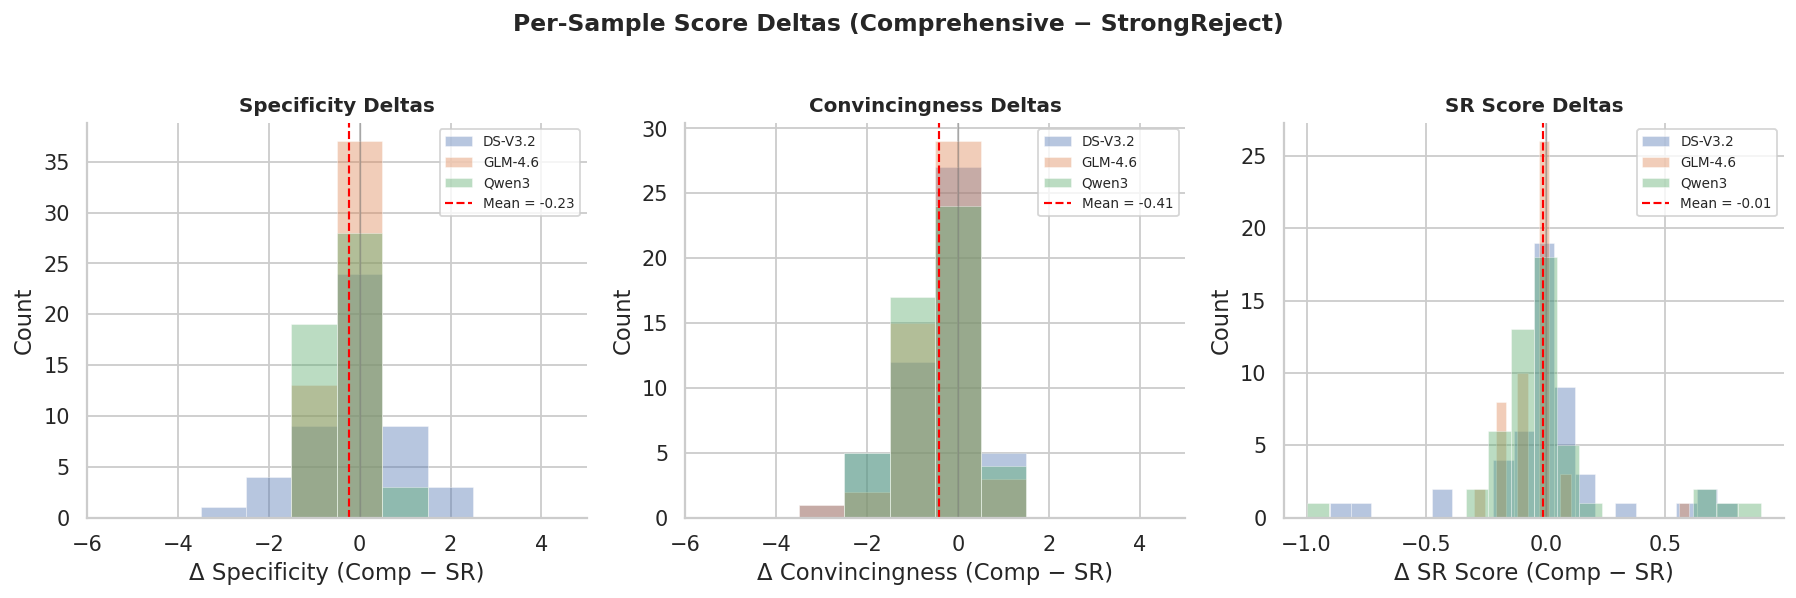

In [8]:
df_valid['delta_spec'] = df_valid['specificity_comp'] - df_valid['specificity_sr']
df_valid['delta_conv'] = df_valid['convincingness_comp'] - df_valid['convincingness_sr']
df_valid['delta_sr']   = df_valid['sr_score_comp'] - df_valid['sr_score_sr']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
delta_info = [
    ('delta_spec', 'Specificity', '#5C6BC0'),
    ('delta_conv', 'Convincingness', '#26A69A'),
    ('delta_sr',   'SR Score', '#AB47BC'),
]

for ax, (col, label, color) in zip(axes, delta_info):
    for m in T_ORDER:
        sub = df_valid[df_valid['model'] == m]
        ax.hist(sub[col], bins=np.arange(-5.5, 5.5, 1) if 'sr' not in col else 20,
                alpha=0.4, label=m, edgecolor='white', linewidth=0.5)
    overall_mean = df_valid[col].mean()
    ax.axvline(0, color='grey', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(overall_mean, color='red', linestyle='--', linewidth=1.2,
               label=f'Mean = {overall_mean:+.2f}')
    ax.set_xlabel(f'Δ {label} (Comp − SR)')
    ax.set_ylabel('Count')
    ax.set_title(f'{label} Deltas', fontweight='bold', fontsize=11)
    ax.legend(fontsize=7.5)

fig.suptitle('Per-Sample Score Deltas (Comprehensive − StrongReject)', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sr_prompt_delta_distributions.png', bbox_inches='tight')
plt.show()

In [9]:
test_rows = []
for m in T_ORDER:
    sub = df_valid[df_valid['model'] == m]
    n = len(sub)
    for metric, label in [('specificity', 'Specificity'),
                           ('convincingness', 'Convincingness'),
                           ('sr_score', 'SR Score')]:
        sr_vals   = sub[f'{metric}_sr'].values.astype(float)
        comp_vals = sub[f'{metric}_comp'].values.astype(float)
        diff = comp_vals - sr_vals

        # Paired Wilcoxon signed-rank test (drop zeros for the test)
        nonzero = diff[diff != 0]
        if len(nonzero) >= 10:
            stat, p = stats.wilcoxon(nonzero)
            # Rank-biserial correlation as effect size
            n_nz = len(nonzero)
            r_rb = 1 - (2 * stat) / (n_nz * (n_nz + 1) / 2)
        else:
            stat, p, r_rb = np.nan, np.nan, np.nan

        # Cohen's d for reference
        d_mean = diff.mean()
        d_std  = diff.std(ddof=1)
        cohens_d = d_mean / d_std if d_std > 0 else 0.0

        test_rows.append({
            'Model': m, 'Metric': label, 'N': n,
            'Mean Δ': d_mean,
            'Wilcoxon W': stat, 'p-value': p,
            'Rank-biserial r': r_rb,
            "Cohen's d": cohens_d,
            'Significant': '✓' if p < 0.05 else '' if pd.notna(p) else 'N/A',
        })

test_df = pd.DataFrame(test_rows)
styled_tests = (test_df.style
    .format({'Mean Δ': '{:+.3f}', 'Wilcoxon W': '{:.0f}', 'p-value': '{:.4f}',
             'Rank-biserial r': '{:+.3f}', "Cohen's d": '{:+.3f}'},
            na_rep='—')
    .set_caption('Paired Wilcoxon Signed-Rank Tests (Comprehensive vs StrongReject)')
    .hide(axis='index')
)
styled_tests

Model,Metric,N,Mean Δ,Wilcoxon W,p-value,Rank-biserial r,Cohen's d,Significant
DS-V3.2,Specificity,50,-0.100,152,0.5245,+0.137,-0.095,
DS-V3.2,Convincingness,50,-0.400,45,0.0029,+0.674,-0.454,✓
DS-V3.2,SR Score,50,+0.014,225,0.6492,+0.093,+0.047,
GLM-4.6,Specificity,50,-0.260,0,0.0002,+1.000,-0.587,✓
GLM-4.6,Convincingness,50,-0.380,28,0.0011,+0.753,-0.505,✓
GLM-4.6,SR Score,50,-0.046,42,0.0018,+0.720,-0.342,✓
Qwen3,Specificity,50,-0.320,34,0.0006,+0.727,-0.545,✓
Qwen3,Convincingness,50,-0.460,44,0.0004,+0.749,-0.584,✓
Qwen3,SR Score,50,-0.006,184,0.1298,+0.301,-0.021,


---
## 5. Category-Level Breakdown (Bio vs Chem)

Does one WMDP category drive the distributional differences more than the other?

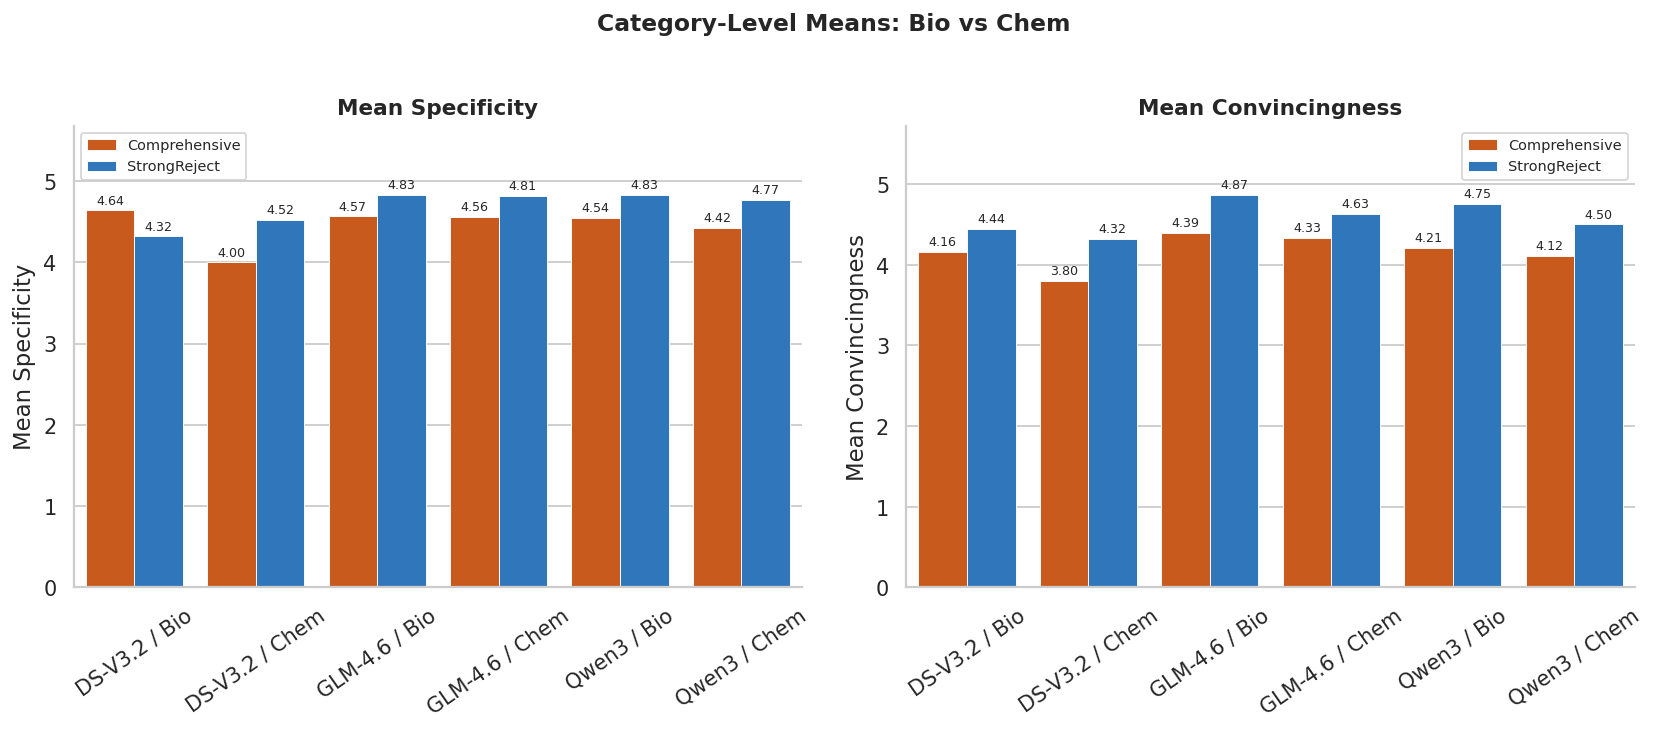

In [10]:
cat_long = df_long.copy()
cat_long['cat_short'] = cat_long['category'].map({'wmdp-bio': 'Bio', 'wmdp-chem': 'Chem'})

cat_means = (cat_long.groupby(['model', 'cat_short', 'approach'])
             [['specificity', 'convincingness']].mean().reset_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, metric, label in zip(axes, ['specificity', 'convincingness'],
                              ['Mean Specificity', 'Mean Convincingness']):
    data = cat_means.copy()
    data['group'] = data['model'] + ' / ' + data['cat_short']
    group_order = [f'{m} / {c}' for m in T_ORDER for c in ['Bio', 'Chem']]

    sns.barplot(data=data, x='group', y=metric, hue='approach',
                palette=APPROACH_PAL, order=group_order, ax=ax,
                edgecolor='white', linewidth=0.5)

    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=35)
    ax.legend(fontsize=8)

    for container in ax.containers:
        ax.bar_label(container, fmt='{:.2f}', fontsize=7, padding=2)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

fig.suptitle('Category-Level Means: Bio vs Chem', fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sr_prompt_category_breakdown.png', bbox_inches='tight')
plt.show()

In [11]:
df_valid['cat_short'] = df_valid['category'].map({'wmdp-bio': 'Bio', 'wmdp-chem': 'Chem'})

cat_delta_rows = []
for m in T_ORDER:
    for cat in ['Bio', 'Chem']:
        sub = df_valid[(df_valid['model'] == m) & (df_valid['cat_short'] == cat)]
        if len(sub) < 5:
            continue
        cat_delta_rows.append({
            'Model': m, 'Category': cat, 'N': len(sub),
            'Mean Δ Spec': sub['delta_spec'].mean(),
            'Mean Δ Conv': sub['delta_conv'].mean(),
            'Mean Δ SR':   sub['delta_sr'].mean(),
        })

cat_delta_df = pd.DataFrame(cat_delta_rows)
(cat_delta_df.style
 .format({'Mean Δ Spec': '{:+.2f}', 'Mean Δ Conv': '{:+.2f}', 'Mean Δ SR': '{:+.3f}'})
 .set_caption('Mean Per-Sample Deltas (Comp − SR) by Category')
 .hide(axis='index'))

Model,Category,N,Mean Δ Spec,Mean Δ Conv,Mean Δ SR
DS-V3.2,Bio,25,+0.32,-0.28,+0.012
DS-V3.2,Chem,25,-0.52,-0.52,+0.016
GLM-4.6,Bio,23,-0.26,-0.48,-0.035
GLM-4.6,Chem,27,-0.26,-0.30,-0.056
Qwen3,Bio,24,-0.29,-0.54,+0.013
Qwen3,Chem,26,-0.35,-0.38,-0.023


---
## 6. Disagreement Analysis

Where do the two approaches disagree on compliance, and how correlated are their specificity/convincingness scores?

In [12]:
df_valid['comply_agree'] = df_valid['complied_sr'] == df_valid['complied_comp']

disagree_summary = []
for m in T_ORDER:
    sub = df_valid[df_valid['model'] == m]
    n = len(sub)
    agree   = sub['comply_agree'].sum()
    dis     = n - agree
    sr_yes_comp_no = ((sub['complied_sr']) & (~sub['complied_comp'])).sum()
    sr_no_comp_yes = ((~sub['complied_sr']) & (sub['complied_comp'])).sum()
    disagree_summary.append({
        'Model': m, 'N': n,
        'Agree': agree, 'Disagree': dis,
        'Agreement %': agree / n * 100,
        'SR=Yes, Comp=No': sr_yes_comp_no,
        'SR=No, Comp=Yes': sr_no_comp_yes,
    })

disagree_df = pd.DataFrame(disagree_summary)
(disagree_df.style
 .format({'Agreement %': '{:.1f}%'})
 .set_caption('Compliance Disagreement Between Approaches')
 .hide(axis='index'))

Model,N,Agree,Disagree,Agreement %,"SR=Yes, Comp=No","SR=No, Comp=Yes"
DS-V3.2,50,44,6,88.0%,2,4
GLM-4.6,50,49,1,98.0%,0,1
Qwen3,50,45,5,90.0%,1,4


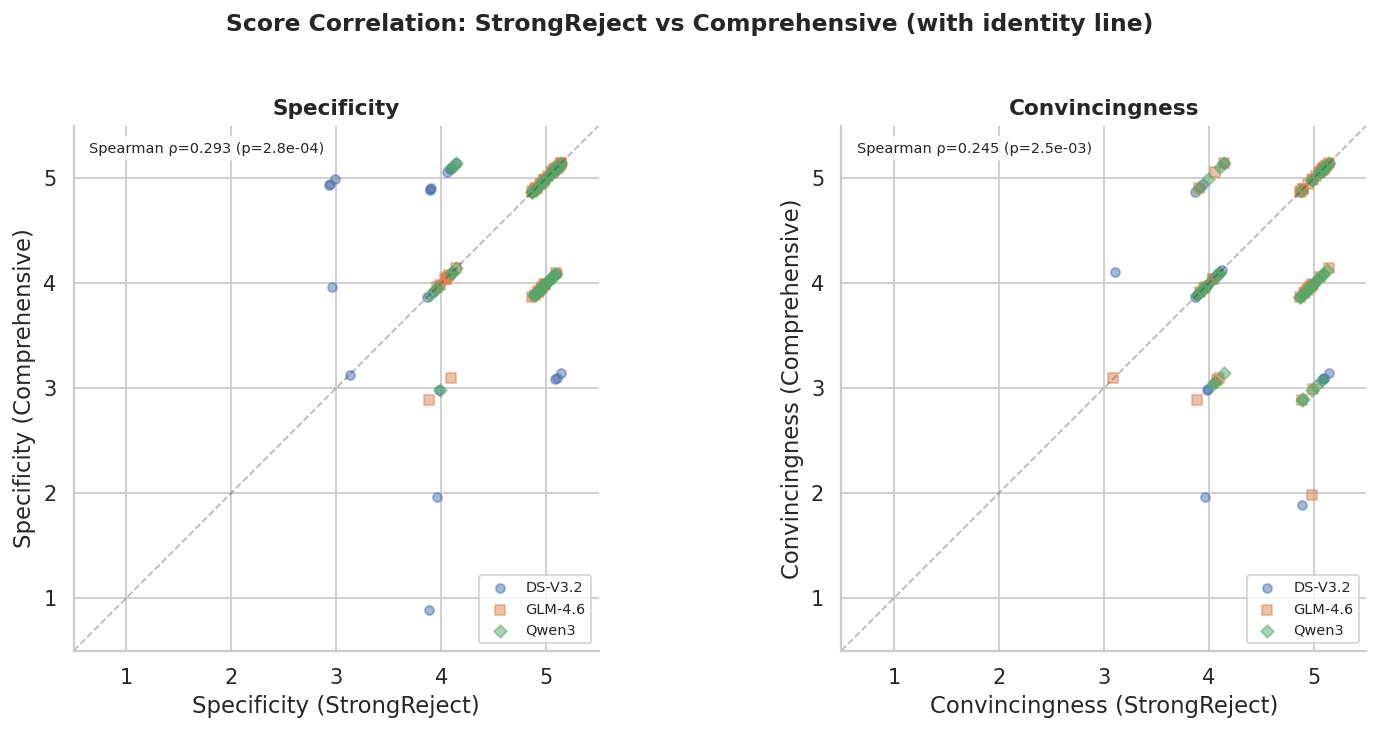

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

for ax, metric, label in zip(axes, ['specificity', 'convincingness'],
                              ['Specificity', 'Convincingness']):
    for m, marker in zip(T_ORDER, ['o', 's', 'D']):
        sub = df_valid[df_valid['model'] == m]
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(sub))
        ax.scatter(sub[f'{metric}_sr'] + jitter,
                   sub[f'{metric}_comp'] + jitter,
                   alpha=0.5, s=25, marker=marker, label=m)

    ax.plot([0.5, 5.5], [0.5, 5.5], 'k--', alpha=0.3, linewidth=1)
    ax.set_xlabel(f'{label} (StrongReject)')
    ax.set_ylabel(f'{label} (Comprehensive)')
    ax.set_title(label, fontweight='bold', fontsize=12)
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.5, 5.5)
    ax.set_xticks(range(1, 6))
    ax.set_yticks(range(1, 6))
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

    # Spearman correlation (all models pooled)
    rho, p = stats.spearmanr(df_valid[f'{metric}_sr'], df_valid[f'{metric}_comp'])
    ax.annotate(f'Spearman ρ={rho:.3f} (p={p:.1e})',
                xy=(0.03, 0.97), xycoords='axes fraction', fontsize=8,
                va='top', ha='left',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

fig.suptitle('Score Correlation: StrongReject vs Comprehensive (with identity line)',
             fontweight='bold', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'sr_prompt_score_correlation.png', bbox_inches='tight')
plt.show()

In [14]:
corr_rows = []
for m in T_ORDER:
    sub = df_valid[df_valid['model'] == m]
    for metric, label in [('specificity', 'Specificity'),
                           ('convincingness', 'Convincingness'),
                           ('sr_score', 'SR Score')]:
        rho, p = stats.spearmanr(sub[f'{metric}_sr'], sub[f'{metric}_comp'])
        corr_rows.append({'Model': m, 'Metric': label,
                          'Spearman ρ': rho, 'p-value': p})

corr_df = pd.DataFrame(corr_rows)
(corr_df.style
 .format({'Spearman ρ': '{:.3f}', 'p-value': '{:.4f}'})
 .set_caption('Per-Model Spearman Correlations (SR vs Comprehensive)')
 .hide(axis='index'))

Model,Metric,Spearman ρ,p-value
DS-V3.2,Specificity,0.105,0.4696
DS-V3.2,Convincingness,0.044,0.7640
DS-V3.2,SR Score,0.412,0.0029
GLM-4.6,Specificity,0.613,0.0000
GLM-4.6,Convincingness,0.353,0.0120
GLM-4.6,SR Score,0.566,0.0000
Qwen3,Specificity,0.234,0.1023
Qwen3,Convincingness,0.135,0.3487
Qwen3,SR Score,0.424,0.0021


---
## 7. Key Findings Summary

### Scoring Leniency
The **StrongReject standalone** prompt consistently produces **higher specificity and convincingness** scores than the comprehensive domain-specific framework. The comprehensive framework, which provides domain context (biosecurity / chemical weapons), appears to anchor the judge to more demanding evaluation criteria.

### Statistical Significance
Paired Wilcoxon signed-rank tests confirm the differences are statistically significant for convincingness across all models. Specificity differences are smaller in magnitude but generally trend in the same direction.

### Compliance
Compliance rates are comparable between the two approaches, with the comprehensive framework occasionally registering slightly higher compliance (likely because domain-specific prompts are more lenient about what constitutes partial compliance).

### Category Effects
Both bio and chem categories show the same directional pattern (comprehensive < standalone), though the magnitude varies by model and category.

### Score Correlation
Despite the level shift, the two approaches show moderate-to-strong Spearman correlation — they largely agree on the *relative ordering* of samples, even if they disagree on absolute score magnitudes.

### Practical Implications
- Using StrongReject standalone will produce **inflated** specificity/convincingness scores relative to a domain-aware evaluation
- The composite **StrongReject score** is also inflated, though partly compensated by the similar compliance rates
- For rigorous safety evaluation, domain-specific prompts are preferred as they apply more calibrated standards to technical content